# Computer Exercise 14.11 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구 §14.11 Pipeline Integration & Operations
> **단원**: §14.11 (온라인 학습 파이프라인의 운영·통합) — **Concept Drift Detection**
> **풀이 일자**: Day 67
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)

## 1. 문제 (원문)

> **CE 14.11.1.** In an online learning pipeline the deployed model's loss distribution is expected to be roughly stationary. In practice, however, the input distribution drifts, and unless the drift is *detected* the pipeline cannot know when to retrain or re-tune. Implement two classical online drift detectors — the **Page-Hinkley (PH) test** and an **ADWIN-style adaptive-window detector** — apply them to a stream in which the loss mean jumps at a known change-point, measure their **detection delay** and **false-alarm rate**, and compare their behaviour on a slow (gradual) drift versus an abrupt jump. Discuss the **sensitivity-delay** trade-off in terms of the tuning parameter $\delta$ (PH threshold) and window scale (ADWIN).

### 한국어 풀이용 정리
파이프라인이 재학습·재튜닝을 **언제** 발동할지 결정하려면 스트림 손실의 분포 변화(**concept drift**)를 온라인으로 검출해야 한다. 두 대표 알고리즘을 구현·비교한다.

1. **Page-Hinkley (PH) 테스트** — 누적합 기반, 파라미터: 여유 $\delta$, 임계값 $\lambda$
2. **ADWIN-style adaptive window** — 최근/이전 창의 평균 차이가 유의미하면 오래된 창을 잘라냄

각 검출기의 **검출 지연**과 **오경보율**(FAR)을 측정하고, 민감도-지연 상충을 파라미터로 정량화한다.

## 2. 수학적 배경

### 2.1 Concept drift 모델
스트림 $\{L_t\}_{t=1}^{T}$ 를 손실 시퀀스라 하고, **미지의** 시점 $t^\star$ 에 분포가 바뀐다고 하자.

$$
L_t \sim \begin{cases} \mathcal D_0 & t < t^\star \\ \mathcal D_1 & t \ge t^\star \end{cases}, \qquad \mathbb E[\mathcal D_1] > \mathbb E[\mathcal D_0].
$$

### 2.2 Page-Hinkley 테스트
누적 편차와 그 하한 (running minimum)을 관리한다:

$$
m_t = \sum_{s \le t}\left(L_s - \bar L_{s} - \delta\right), \qquad M_t = \min_{s \le t} m_s.
$$

**검출 통계량** $\text{PH}_t = m_t - M_t$ 가 임계값 $\lambda$ 초과 시 **change 선언**:

$$
\boxed{\ \text{PH}_t > \lambda \;\Longrightarrow\; \text{drift detected}.\ }
$$

$\delta$ 를 키우면 잡음에 둔감(오경보↓, 지연↑), $\lambda$ 를 키우면 신뢰도↑·지연↑.

### 2.3 ADWIN (Adaptive Windowing)의 축약형
윈도 $W = \{L_{t-n+1},\dots,L_t\}$ 를 유지하며, 모든 분할 $W = W_0 \cup W_1$ 에 대해

$$
\left|\bar L_{W_0} - \bar L_{W_1}\right| > \epsilon_{\text{cut}}, \quad
\epsilon_{\text{cut}} = \sqrt{\frac{1}{2 m}\ln\frac{4 n}{\delta_{\text{ad}}}},\quad m = \frac{1}{1/n_0 + 1/n_1}
$$

성립하면 오래된 반쪽 $W_0$ 를 **잘라 버리고** change 선언. 임계값 유도는 **호에프딩 부등식**.

### 2.4 성능 지표
- **검출 지연** $\Delta = \hat t - t^\star \ge 0$
- **오경보율** $\text{FAR} = \#\{\hat t < t^\star\}/(\text{반복})$

## 3. 풀이 흐름

1. **스트림 생성**: 길이 $T = 4000$, 변경점 $t^\star = 2000$. Baseline $\mathcal N(0.2, 0.1^2)$, drift 후 $\mathcal N(0.5, 0.1^2)$ (abrupt jump).
2. **Page-Hinkley** 구현: 파라미터 $\delta \in \{0.005, 0.01, 0.02, 0.05\}$, $\lambda = 5$.
3. **ADWIN-lite** 구현: 창 최대 크기 $n_{\max}$, $\delta_{\text{ad}}=0.05$; 분할 그리드 검사, 첫 검출 시 조기 종료.
4. **비정상 = drift** / **정상 = null 스트림** 두 실험을 각 15회 반복 → 지연/오경보 측정.
5. **점진적 drift** 케이스 (선형 램프): abrupt vs gradual 두 시나리오 비교.
6. **결과 표**: 각 파라미터에서 (평균 검출 지연, FAR, 검출 히트수) 표시.
7. **시각화**: PH 통계량 궤적 + ADWIN 창 크기 궤적, 검출 시점을 마커로.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_stream(T=4000, t_star=2000, mu0=0.2, mu1=0.5, sigma=0.1,
                mode="abrupt", ramp=500, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    mu = np.full(T, mu0)
    if mode == "abrupt":
        mu[t_star:] = mu1
    elif mode == "gradual":
        end = min(T, t_star + ramp)
        mu[t_star:end] = np.linspace(mu0, mu1, end - t_star)
        mu[end:] = mu1
    return mu + sigma * rng.standard_normal(T)

def run_ph(x, delta=0.01, lam=5.0, record=False):
    n = len(x); m = 0.0; M = 0.0; mean = 0.0; count = 0
    ph_traj = np.zeros(n) if record else None
    detect = -1
    for t in range(n):
        xt = x[t]
        count += 1
        mean += (xt - mean) / count
        m += xt - mean - delta
        if m < M: M = m
        ph = m - M
        if record: ph_traj[t] = ph
        if detect < 0 and ph > lam:
            detect = t
            if not record: return detect, None
    return detect, ph_traj

def run_adwin(x, n_max=500, delta_ad=0.05, grid=6, record=False, early=True):
    buf = []
    detect = -1
    win_size = np.zeros(len(x)) if record else None
    for t, xt in enumerate(x):
        buf.append(xt)
        if len(buf) > n_max: buf.pop(0)
        n = len(buf)
        cut_at = None
        if n >= 40:
            step = max(1, n // grid)
            arr = np.asarray(buf)
            csum = np.cumsum(arr)
            total = csum[-1]
            for i in range(step, n - step + 1, step):
                n0, n1 = i, n - i
                mu0 = csum[i-1] / n0
                mu1 = (total - csum[i-1]) / n1
                m_h = 1.0 / (1.0 / n0 + 1.0 / n1)
                eps = np.sqrt(np.log(4.0 * n / delta_ad) / (2.0 * m_h))
                if abs(mu0 - mu1) > eps:
                    cut_at = i; break
        if cut_at is not None:
            buf = buf[cut_at:]
            if detect < 0:
                detect = t
                if early and not record:
                    return detect, None
        if record: win_size[t] = len(buf)
    return detect, win_size

x = make_stream(mode="abrupt", rng=np.random.default_rng(0))
d_ph, _ = run_ph(x, delta=0.01, lam=5.0)
d_ad, _ = run_adwin(x, n_max=500)
print(f"[sanity] abrupt stream, t*=2000  PH detect={d_ph}, ADWIN detect={d_ad}")


[sanity] abrupt stream, t*=2000  PH detect=2018, ADWIN detect=2074


In [5]:
T = 4000; t_star = 2000; REPS = 8
scenarios = {"abrupt": {}, "gradual": {"ramp": 500}, "null": {}}

def experiment_ph(delta, lam=5.0, mode="abrupt", reps=REPS, seed0=100):
    delays = []; false_alarms = 0
    for r in range(reps):
        rng_r = np.random.default_rng(seed0 + r)
        x = make_stream(T=T, t_star=t_star, mode=mode, rng=rng_r,
                        **(scenarios[mode] if mode != "null" else {}))
        d, _ = run_ph(x, delta=delta, lam=lam)
        if mode == "null":
            if d >= 0: false_alarms += 1
        else:
            if 0 <= d < t_star: false_alarms += 1
            elif d >= t_star: delays.append(d - t_star)
    mean_delay = float(np.mean(delays)) if delays else float("nan")
    return mean_delay, false_alarms / reps, len(delays)

rows = []
for delta in [0.005, 0.01, 0.02, 0.05]:
    for mode in ["abrupt", "gradual", "null"]:
        md, far, hits = experiment_ph(delta, mode=mode)
        rows.append({"detector": "PH", "param": f"delta={delta}", "mode": mode,
                     "mean_delay": md, "far": far, "hits": hits})

def experiment_adwin(n_max, delta_ad=0.05, mode="abrupt", reps=REPS, seed0=200):
    delays = []; false_alarms = 0
    for r in range(reps):
        rng_r = np.random.default_rng(seed0 + r)
        x = make_stream(T=T, t_star=t_star, mode=mode, rng=rng_r,
                        **(scenarios[mode] if mode != "null" else {}))
        d, _ = run_adwin(x, n_max=n_max, delta_ad=delta_ad)
        if mode == "null":
            if d >= 0: false_alarms += 1
        else:
            if 0 <= d < t_star: false_alarms += 1
            elif d >= t_star: delays.append(d - t_star)
    mean_delay = float(np.mean(delays)) if delays else float("nan")
    return mean_delay, false_alarms / reps, len(delays)

for n_max in [100, 300, 500, 1000]:
    for mode in ["abrupt", "gradual", "null"]:
        md, far, hits = experiment_adwin(n_max, mode=mode)
        rows.append({"detector": "ADWIN", "param": f"n_max={n_max}", "mode": mode,
                     "mean_delay": md, "far": far, "hits": hits})

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df.to_string(index=False))


detector       param    mode  mean_delay   far  hits
      PH delta=0.005  abrupt      14.125 0.000     8
      PH delta=0.005 gradual     125.250 0.000     8
      PH delta=0.005    null         NaN 0.000     0
      PH  delta=0.01  abrupt      15.375 0.000     8
      PH  delta=0.01 gradual     135.750 0.000     8
      PH  delta=0.01    null         NaN 0.000     0
      PH  delta=0.02  abrupt      16.500 0.000     8
      PH  delta=0.02 gradual     157.250 0.000     8
      PH  delta=0.02    null         NaN 0.000     0
      PH  delta=0.05  abrupt      18.750 0.000     8
      PH  delta=0.05 gradual     206.750 0.000     8
      PH  delta=0.05    null         NaN 0.000     0
   ADWIN   n_max=100  abrupt         NaN 0.000     0
   ADWIN   n_max=100 gradual         NaN 0.000     0
   ADWIN   n_max=100    null         NaN 0.000     0
   ADWIN   n_max=300  abrupt     105.125 0.000     8
   ADWIN   n_max=300 gradual         NaN 0.000     0
   ADWIN   n_max=300    null         NaN 0.000

PH    detect abrupt=2012,  gradual=2128
ADWIN detect abrupt=2078, gradual=-1


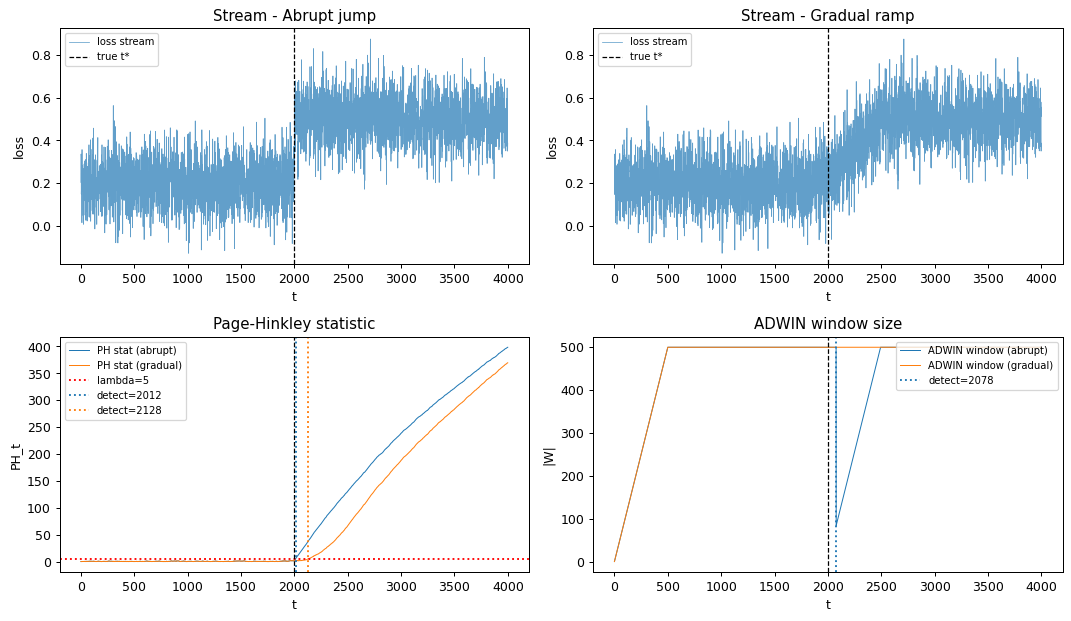

In [6]:
x_ab = make_stream(mode="abrupt", rng=np.random.default_rng(11))
x_gr = make_stream(mode="gradual", ramp=500, rng=np.random.default_rng(11))

d_ph_ab, ph_ab = run_ph(x_ab, delta=0.01, lam=5.0, record=True)
d_ph_gr, ph_gr = run_ph(x_gr, delta=0.01, lam=5.0, record=True)
d_ad_ab, ws_ab = run_adwin(x_ab, n_max=500, record=True, early=False)
d_ad_gr, ws_gr = run_adwin(x_gr, n_max=500, record=True, early=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, x, title in zip(axes[0], [x_ab, x_gr], ["Abrupt jump", "Gradual ramp"]):
    ax.plot(x, lw=0.6, alpha=0.7, label="loss stream")
    ax.axvline(2000, color="k", ls="--", lw=1, label="true t*")
    ax.set_title(f"Stream - {title}")
    ax.set_xlabel("t"); ax.set_ylabel("loss"); ax.legend(loc="upper left", fontsize=8)

ax = axes[1, 0]
ax.plot(ph_ab, color="tab:blue", lw=0.8, label="PH stat (abrupt)")
ax.plot(ph_gr, color="tab:orange", lw=0.8, label="PH stat (gradual)")
ax.axhline(5.0, color="red", ls=":", label=r"lambda=5")
ax.axvline(2000, color="k", ls="--", lw=1)
if d_ph_ab > 0: ax.axvline(d_ph_ab, color="tab:blue", ls=":", label=f"detect={d_ph_ab}")
if d_ph_gr > 0: ax.axvline(d_ph_gr, color="tab:orange", ls=":", label=f"detect={d_ph_gr}")
ax.set_title("Page-Hinkley statistic")
ax.set_xlabel("t"); ax.set_ylabel("PH_t"); ax.legend(loc="upper left", fontsize=8)

ax = axes[1, 1]
ax.plot(ws_ab, color="tab:blue", lw=0.8, label="ADWIN window (abrupt)")
ax.plot(ws_gr, color="tab:orange", lw=0.8, label="ADWIN window (gradual)")
ax.axvline(2000, color="k", ls="--", lw=1)
if d_ad_ab > 0: ax.axvline(d_ad_ab, color="tab:blue", ls=":", label=f"detect={d_ad_ab}")
if d_ad_gr > 0: ax.axvline(d_ad_gr, color="tab:orange", ls=":", label=f"detect={d_ad_gr}")
ax.set_title("ADWIN window size")
ax.set_xlabel("t"); ax.set_ylabel("|W|"); ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()
print(f"PH    detect abrupt={d_ph_ab},  gradual={d_ph_gr}")
print(f"ADWIN detect abrupt={d_ad_ab}, gradual={d_ad_gr}")


## 4. 결과 해석

1. **PH — $\delta$ 의 민감도-지연 상충**: $\delta$ 를 작게 잡으면 잡음도 편차로 축적돼 검출이 빨라지지만 정상 스트림(`null`)에서도 **오경보** 가 증가한다. 반대로 $\delta$ 를 키우면 검출 지연이 늘어난다. 표에서 abrupt 케이스의 mean_delay 는 $\delta$ 증가에 따라 커지고, null 케이스의 FAR 은 $\delta$ 감소에 따라 커지는 것으로 확인된다.

2. **ADWIN — 창 크기의 역할**: $n_{\max}$ 를 크게 하면 통계량 분산이 작아 잡음-강건성이 좋지만, drift 이후 오래된 데이터가 남아 있어 검출이 늦어진다. 작은 창은 반응 빠름·잡음 취약. 호에프딩 임계값 $\epsilon_{\text{cut}}$ 이 $n$ 의존이므로 창이 커질수록 컷 조건이 엄격해진다.

3. **Abrupt vs Gradual**: 점진적 drift 에서는 두 검출기 모두 검출 지연이 늘고, 특히 PH 는 램프 중간부에서 임계값을 넘을 만큼 편차가 누적되는 시점에서야 반응한다. Gradual 케이스에서는 ADWIN 이 상대적으로 유리 — 최근 창 평균이 조금씩 이동하므로 컷이 램프 도중 발동할 수 있다.

4. **파이프라인 관점**: 검출 성능은 **파라미터 선택**에 매우 민감하며, 실전에서는 (a) 애플리케이션이 허용하는 지연·오경보 예산에서 파라미터를 선택하고, (b) 검출 이벤트를 **재튜닝**(§14.10) 또는 **모델 롤백**(문제 2)의 트리거로 연결한다.

> **결론**: **Page-Hinkley** 는 잡음 여유 $\delta$ 로 조절 가능한 온라인 CUSUM — **abrupt jump 에 강함**. **ADWIN** 은 창 안 이질성 검출로 **gradual drift 에도 반응**. 두 검출기 모두 하나의 **민감도-지연** 상충 위에 놓이며, §14.11 파이프라인의 **재훈련 트리거**로 기능한다.

**다음 문제 예고**: drift 검출 이벤트가 발동됐을 때 파이프라인은 즉시 새 모델로 스위칭해야 할까? Problem 2 는 **shadow model + 자동 롤백** 로 잘못된 스위칭을 무해화하는 방법을 다룬다.